In [ ]:
import os
import pandas as pd
from utils import DATASETS, plot_bar

plot_dir = f'../plot/others'
os.makedirs(plot_dir, exist_ok=True)

question_nums, testtaker_nums = [], []
for dataset in DATASETS:
    y = pd.read_csv(f'../data/pre_calibration/{dataset}/matrix.csv', index_col=0).values
    testtaker_nums.append(y.shape[0])
    question_nums.append(y.shape[1])

plot_bar(DATASETS, question_nums, f"{plot_dir}/question_nums.png", r"Number of Questions", exp_axis=True)
plot_bar(DATASETS, testtaker_nums, f"{plot_dir}/testtaker_nums.png", r"Number of Test Takers")

/Users/tyhhh/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyError: 'train'

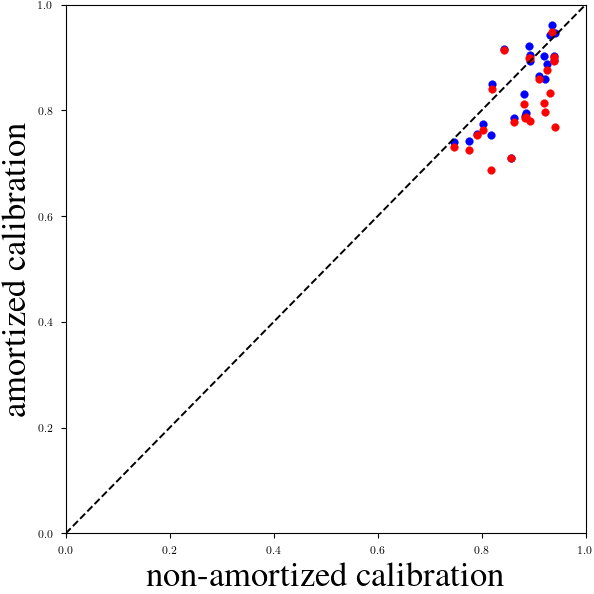

In [1]:

import pandas as pd
from utils import plot_corr, plot_corr_double
import os

plot_dir = f'../plot/overall'
os.makedirs(plot_dir, exist_ok=True)

nonamor_gof = pd.read_csv(f'../plot/nonamor_calibration/nonamor_calibration_gof.csv')["gof_means"].values
amor_gof_train = pd.read_csv(f'../plot/amor_calibration/amor_calibration_gof_train.csv')["gof_means"].values
amor_gof_test = pd.read_csv(f'../plot/amor_calibration/amor_calibration_gof_test.csv')["gof_means"].values
plugin_gof_train = pd.read_csv(f'../plot/plugin_regression/plugin_regression_gof_train.csv')["gof_means"].values
plugin_gof_test = pd.read_csv(f'../plot/plugin_regression/plugin_regression_gof_test.csv')["gof_means"].values

nonamor_ctt = pd.read_csv(f'../plot/nonamor_calibration/nonamor_calibration_corr_ctt.csv')["corr_ctt_means"].values
amor_ctt = pd.read_csv(f'../plot/amor_calibration/amor_calibration_corr_ctt.csv')["corr_ctt_means"].values

# nonamor_helm = pd.read_csv(f'../plot/nonamor_calibration/nonamor_calibration_corr_helm.csv')["corr_helm_means"].values
# amor_helm = pd.read_csv(f'../plot/amor_calibration/amor_calibration_corr_helm.csv')["corr_helm_means"].values

plot_corr(
    data1=nonamor_ctt,
    data2=amor_ctt,
    plot_path=f"{plot_dir}/ctt_nonamor_amor.png",
    title=r'Theta correlation with CTT. $\rho$ = {:.2f}',
    xlabel=r"non-amortized calibration",
    ylabel=r"amortized calibration",
)

# plot_corr(
#     data1=nonamor_helm,
#     data2=amor_helm,
#     plot_path=f"{plot_dir}/helm_nonamor_amor.png",
#     xlabel=r"non-amortized calibration theta correlation with HELM",
#     ylabel=r"amortized calibration theta correlation with HELM",
# )

plot_corr_double(
    data1_train=nonamor_gof,
    data1_test=nonamor_gof,
    data2_train=amor_gof_train,
    data2_test=amor_gof_test,
    plot_path=f"{plot_dir}/gof_nonamor_amor.png",
    title=r'Goodness of Fit Correlation. $\rho_{train}$ = {:.2f}, $\rho_{test}$ = {:.2f}',
    xlabel=r"non-amortized calibration",
    ylabel=r"amortized calibration",
)

plot_corr_double(
    data1_train=nonamor_gof,
    data1_test=nonamor_gof,
    data2_train=plugin_gof_train,
    data2_test=plugin_gof_test,
    plot_path=f"{plot_dir}/gof_nonamor_plungin.png",
    title=r'Goodness of Fit Correlation. $\rho_{train}$ = {:.2f}, $\rho_{test}$ = {:.2f}',
    xlabel=r"non-amortized calibration",
    ylabel=r"plug-in regression",
)